In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [54]:
X,y_true=make_blobs(n_samples=500,centers=3,cluster_std=4,random_state=42)

In [55]:
df=pd.DataFrame(X, columns=['Feature 1','Feature 2'])
df

,Feature 1,Feature 2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868
...,...,...
495,-1.282205,-3.181575
496,-2.817604,10.378894
497,3.296740,8.649256
498,-8.970519,-2.684073


In [56]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

In [57]:
inertia=[]
K_range=range(1,11)

In [58]:
for k in K_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [59]:
inertia

[999.9999999999993,
 528.8064432605648,
 294.4377068678187,
 250.45524696534443,
 216.88110656982602,
 185.27440675195902,
 156.7087999629044,
 135.62603453115247,
 129.1039634823981,
 119.94101297104989]

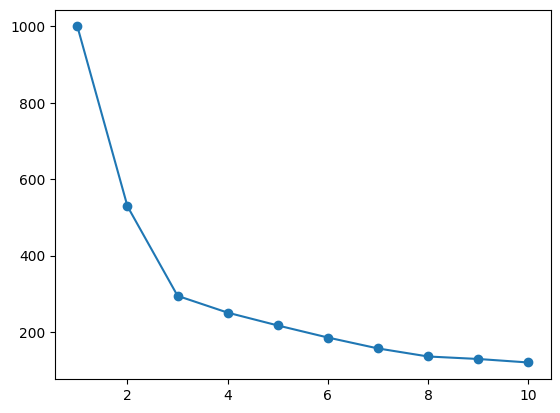

In [60]:
plt.plot(K_range,inertia,marker='o')

In [61]:
kmeans_final=KMeans(n_clusters=3,random_state=42)

In [62]:
cluster_labels=kmeans_final.fit_predict(X_scaled)
df['cluster']=cluster_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

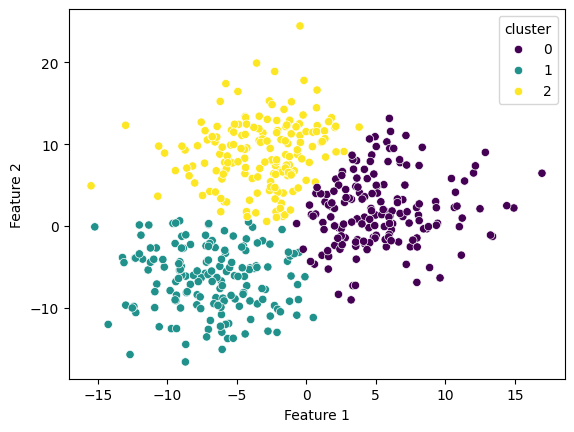

In [63]:
sns.scatterplot(x=df['Feature 1'],
                y=df['Feature 2'],
                hue=df['cluster'],
                palette='viridis')

In [64]:
from sklearn.datasets import make_moons

In [66]:
X1,y1_true=make_moons(n_samples=500,noise=0.05,random_state=42)

In [67]:
from sklearn.cluster import KMeans,DBSCAN

In [70]:
df1=pd.DataFrame(X1,columns=['Feature 1','Feature 2'])

In [71]:
scaler1=StandardScaler()
X1_scaled=scaler1.fit_transform(df1)

In [73]:
kmeans1=KMeans(n_clusters=2,random_state=42)
kmeans_labels=kmeans1.fit_predict(X1_scaled)
df['kmeans_cluster']=kmeans_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

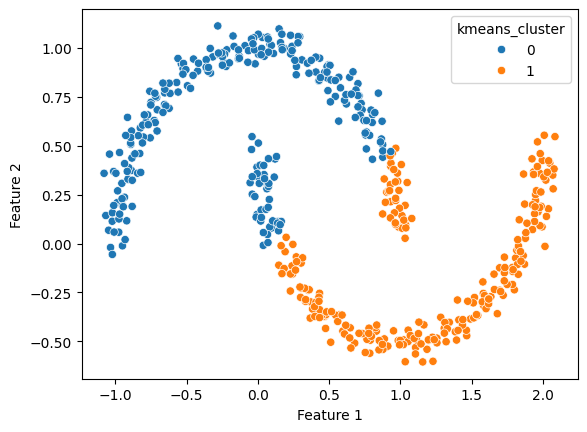

In [74]:
sns.scatterplot(x=df['Feature 1'],
                y=df['Feature 2'],
                hue=df['kmeans_cluster'],
                palette='tab10')

In [79]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
dbscan_labels=dbscan.fit_predict(X1_scaled)

In [80]:
df['dbscan_cluster']=dbscan_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

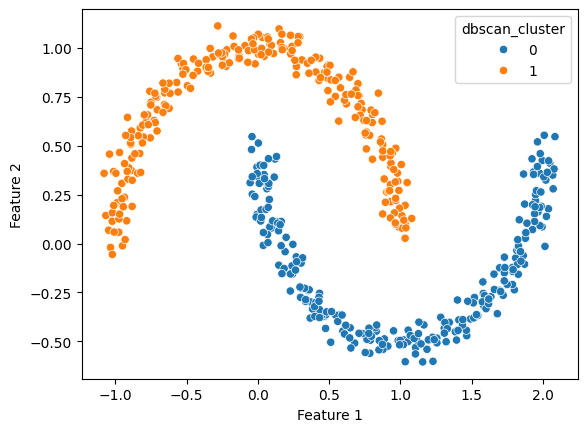

In [81]:
sns.scatterplot(x=df['Feature 1'],
                y=df['Feature 2'],
                hue=df['dbscan_cluster'],
                palette='tab10')